<a href="https://colab.research.google.com/github/amrit2603/Gen-AI/blob/main/LoraFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# **Generate Synthetic House Pricing Data**

In [2]:
# Step 1: LoRA Implementation for Regression Task
# Generate synthetic data for house prices
np.random.seed(42) # ✨with seed 42 we will get same random numbers every time, without seed we will get different random numbers every time
num_samples = 500

# Features: house size (sq ft) and location index
X = np.random.rand(num_samples, 2) * 100 # means 500 samples with 2 features each

# True price equation:
# Price = 50 * Size + 30 * Location + Noise

y = 50 * X[:, 0] + 30 * X[:, 1] + np.random.randn(num_samples) * 10
# [:,0] means all rows and first column
y = y.reshape(-1, 1)

# Split into training and test sets
train_size = int(0.8 * num_samples)
X_train, y_train = X[:train_size], y[:train_size] # meaning first 400 samples , 0 to 399
X_test, y_test = X[train_size:], y[train_size:] # meaning last 100 samples , 400 to 499

print(f"Training Samples: {X_train.shape}, Test Samples: {X_test.shape}")



# Define LoRA Layer
# -------------------------------------------------------------

"""
How This Works:

- W is frozen (not updated during training).
- A and B are trained, capturing task-specific knowledge.
- The LoRA update A · B adapts the model with fewer parameters.
"""

class LoRALayer(tf.keras.layers.Layer):
    def __init__(self, input_dim, output_dim, rank=2, alpha=1.0):
        super(LoRALayer, self).__init__()
        self.rank = rank
        self.alpha = alpha  # scaling factor

        # Main frozen weight matrix
        self.W = self.add_weight(
            shape=(input_dim, output_dim),
            initializer="random_normal",
            trainable=False # W is frozen so cannot be trained
        )

        # LoRA trainable low-rank matrices
        self.A = self.add_weight(
            shape=(input_dim, rank),
            initializer="random_normal",
            trainable=True
        )
        self.B = self.add_weight(
            shape=(rank, output_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, inputs):
        # LoRA update: XAB * alpha
        lora_update = tf.matmul(inputs, self.A)
        lora_update = tf.matmul(lora_update, self.B) * self.alpha

        # Final output: XW + XABα
        return tf.matmul(inputs, self.W) + lora_update
        # X (W + AB α)



# Build Regression Model with LoRA
# -------------------------------------------------------------

input_dim = X_train.shape[1]
output_dim = 1  # Predicting house price

inputs = keras.Input(shape=(input_dim,))
x = LoRALayer(input_dim, 16, rank=2, alpha=1.0)(inputs)  # LoRA applied here
x = layers.ReLU()(x) # Activation
x = layers.Dense(1)(x)  # Final regression output , output has only one neuron, no activation function here because its regression task

model = keras.Model(inputs, x)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

model.summary()



# Train the Model
# -------------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1 # verbose=1 means show progress bar
)

Training Samples: (400, 2), Test Samples: (100, 2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lo_ra_layer (LoRALayer)         │ (None, 16)             │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85 (340.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 32 (128.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 18681428.0000 - val_loss: 15916854.0000
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17926660.0000 - val_loss: 13277436.0000
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12939121.0000 - val_loss: 5741506.5000
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4344672.5000 - val_loss: 178995.2969
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 178809.8750 - val_loss: 133866.5156
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 117149.7812 - val_loss: 87072.4297
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 80979.1250 - val_loss: 58053.2617
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54812.6719 - val_loss: 38955.2266
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38105.2070 - val_loss: 25264.0371
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26420.5605 - val_loss: 15826.8389
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

# **Evaluate Performance**

Test Loss (MSE): 94.31351470947266


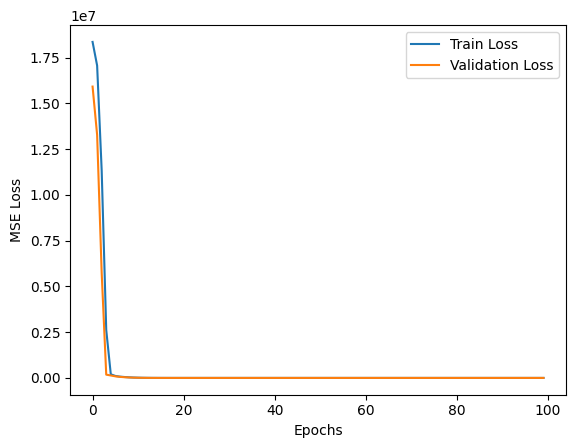

In [3]:
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss}")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()



# Step 2: 4-bit Quantization Functions
# -------------------------------------------------------------

def quantize_4bit(weights):
    """
    Convert weights to 4-bit representation and store scale factor.
    """
    min_w, max_w = np.min(weights), np.max(weights)
    scale = (max_w - min_w) / 15  # 2^4 - 1 = 15 levels in 4-bit
    quantized = np.round((weights - min_w) / scale).astype(np.int8)
    return quantized, min_w, scale


def dequantize_4bit(quantized, min_w, scale):
    """
    Dequantize 4-bit weights back to floating point values.
    """
    return quantized * scale + min_w